In [ ]:
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler , OneHotEncoder , OrdinalEncoder
from sklearn.preprocessing import StandardScaler


In [90]:
df=pd.read_csv("loan_approval_dataset.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Age                1000 non-null   int64 
 1   Salary             1000 non-null   int64 
 2   Credit_Score       1000 non-null   int64 
 3   Loan_Amount        1000 non-null   int64 
 4   Loan_Term          1000 non-null   object
 5   Employment_Status  1000 non-null   object
 6   Residence_Type     1000 non-null   object
 7   Previous_Default   1000 non-null   object
 8   Loan_Approved      1000 non-null   object
dtypes: int64(4), object(5)
memory usage: 70.4+ KB


In [91]:
x=df.drop(columns='Loan_Approved')
y=df.Loan_Approved
xtrain, xtest , ytrain , ytest = train_test_split (x,y,train_size = 0.8 , random_state=42)

In [92]:
x.corr(numeric_only=True)


,Age,Salary,Credit_Score,Loan_Amount
Age,1.000000,0.060125,-0.018835,-0.000500
Salary,0.060125,1.000000,-0.011185,-0.000635
Credit_Score,-0.018835,-0.011185,1.000000,0.008741
Loan_Amount,-0.000500,-0.000635,0.008741,1.000000


In [93]:
num_cols=x.select_dtypes(include='number').columns
obj_cols=x.select_dtypes(include='object').columns

<Axes: >

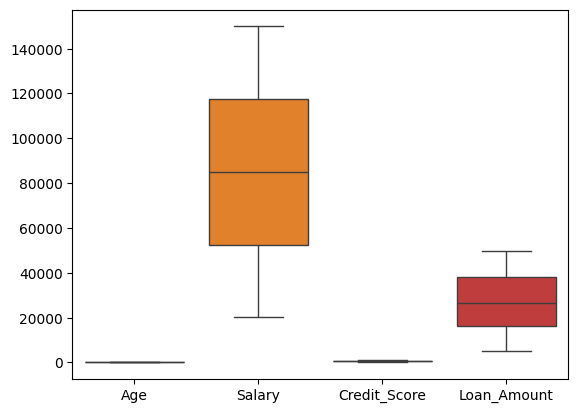

In [94]:
sns.boxplot(x[num_cols])

In [95]:
x[obj_cols].nunique()

Loan_Term            4
Employment_Status    3
Residence_Type       3
Previous_Default     2
dtype: int64

In [96]:
'''pre processing Technique 
   -Scaling
   -Encoding
   
   why scaling? 
   Feature(numerical) cols where values are in diff range (scale) so , we can use sacling to give equal importance
   for all the feature cols
   
   why encoding?
   algorithm can understand only numbers not string
   
   which scaling and encoding technique we can use for this ?

   *Scaling - 1.MinMaxScaler   2.Standardscaler
   
   *Encoding

   Loan_Term            4,
   Employment_Status    3,
   Residence_Type       3,
   Previous_Default     2

   as we can see unique values are less so , we use OneHotEncoder
   '''

'pre processing Technique \n   -Scaling\n   -Encoding\n   \n   why scaling? \n   Feature(numerical) cols where values are in diff range (scale) so , we can use sacling to give equal importance\n   for all the feature cols\n   \n   why encoding?\n   algorithm can understand only numbers not string\n   \n   which scaling and encoding technique we can use for this ?\n\n   *Scaling - 1.MinMaxScaler   2.Standardscaler\n   \n   *Encoding\n\n   Loan_Term            4,\n   Employment_Status    3,\n   Residence_Type       3,\n   Previous_Default     2\n\n   as we can see unique values are less so , we use OneHotEncoder\n   '

In [97]:
encoder = OneHotEncoder(sparse_output=False,handle_unknown='ignore')
scaling = MinMaxScaler()
model = LogisticRegression()

In [98]:
#model.fit(xtrain,ytrain)
'''ValueError: could not convert string
 to float: '48 months'''

"ValueError: could not convert string\n to float: '48 months"

In [99]:
#xtrain
xtrain[num_cols] = scaling.fit_transform(xtrain[num_cols])
#xtrain[obj_cols] = encoder.fit_transform(xtrain[obj_cols])
'''ValueError: Columns must be same length as key'''
encoded_values = encoder.fit_transform(xtrain[obj_cols])
encoded_columns = encoder.get_feature_names_out()

xtrain[encoded_columns] = encoded_values
xtrain.drop(columns=obj_cols,inplace=True)

In [100]:
xtrain

,Age,Salary,Credit_Score,Loan_Amount,Loan_Term_12 months,Loan_Term_24 months,Loan_Term_36 months,Loan_Term_48 months,Employment_Status_Employed,Employment_Status_Self-Employed,Employment_Status_Unemployed,Residence_Type_Mortgage,Residence_Type_Owned,Residence_Type_Rented,Previous_Default_No,Previous_Default_Yes
29,0.565217,0.503206,0.377737,0.267437,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
535,0.434783,0.517503,0.344891,0.125955,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
695,0.586957,0.227507,0.843066,0.766342,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
557,0.630435,0.425421,0.928832,0.792145,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
836,0.608696,0.623919,0.372263,0.599124,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,0.739130,0.759429,0.709854,0.592266,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
270,0.173913,0.889773,0.160584,0.388186,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
860,1.000000,0.884776,0.698905,0.078281,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
435,0.173913,0.213857,0.987226,0.906103,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [101]:
#xtest
xtest[num_cols]=scaling.transform(xtest[num_cols])
xtest_values= encoder.transform(xtest[obj_cols])

encoded_test_cols = encoder.get_feature_names_out()
xtest[encoded_test_cols] = xtest_values
xtest.drop(columns=obj_cols,inplace=True)

In [102]:
xtest

,Age,Salary,Credit_Score,Loan_Amount,Loan_Term_12 months,Loan_Term_24 months,Loan_Term_36 months,Loan_Term_48 months,Employment_Status_Employed,Employment_Status_Self-Employed,Employment_Status_Unemployed,Residence_Type_Mortgage,Residence_Type_Owned,Residence_Type_Rented,Previous_Default_No,Previous_Default_Yes
521,0.152174,0.220886,0.521898,0.540280,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
737,0.434783,0.687894,0.020073,0.453711,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
740,0.347826,0.836468,0.760949,0.652294,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
660,0.434783,0.315031,0.950730,0.116550,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
411,0.934783,0.605720,0.693431,0.587172,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
408,0.782609,0.894307,0.270073,0.867633,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
332,0.347826,0.976689,0.764599,0.938296,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
208,0.478261,0.012071,0.034672,0.038805,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
613,0.086957,0.540937,0.791971,0.830012,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0


In [103]:
model.fit(xtrain,ytrain)

LogisticRegression()

In [104]:
df=pd.read_csv("loan_approval_dataset.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Age                1000 non-null   int64 
 1   Salary             1000 non-null   int64 
 2   Credit_Score       1000 non-null   int64 
 3   Loan_Amount        1000 non-null   int64 
 4   Loan_Term          1000 non-null   object
 5   Employment_Status  1000 non-null   object
 6   Residence_Type     1000 non-null   object
 7   Previous_Default   1000 non-null   object
 8   Loan_Approved      1000 non-null   object
dtypes: int64(4), object(5)
memory usage: 70.4+ KB


In [105]:
from sklearn.metrics import precision_score,recall_score,f1_score,accuracy_score,confusion_matrix
import numpy as np

TRAIN DATA EVALUATION


In [106]:
ytrain_pred = model.predict(xtrain)
matrix=confusion_matrix(ytrain,ytrain_pred)

In [107]:
ytrain.value_counts()

Loan_Approved
Yes    403
No     397
Name: count, dtype: int64

In [108]:
precision_score(ytrain,ytrain_pred,pos_label='Yes')

0.548235294117647

In [109]:
predicted_yes = np.sum(matrix[:,1])
np.sum(matrix[:,0])

np.int64(375)

conclusion : out of all the predicted 'Yes' labels(425), 54% labels are correctly predicted as 'yes'

out of all the predicted 'No' labels(425), 46% labels are wrongly predicted as 'yes'


In [110]:
precision_score(ytrain,ytrain_pred,pos_label='No')

0.5466666666666666

In [111]:
predicted_no = np.sum(matrix[:,1])
np.sum(matrix[:,0])

np.int64(375)

In [112]:
recall_score(ytrain,ytrain_pred,pos_label='Yes')

0.5781637717121588

In [113]:
recall_score(ytrain,ytrain_pred,pos_label='No')


0.5163727959697733

In [114]:
accuracy_score(ytrain,ytrain_pred)

0.5475

conclusion :
Out of all thesample(800)

In [115]:
from sklearn.metrics import classification_report

In [116]:
print(classification_report(ytrain,ytrain_pred))

              precision    recall  f1-score   support

          No       0.55      0.52      0.53       397
         Yes       0.55      0.58      0.56       403

    accuracy                           0.55       800
   macro avg       0.55      0.55      0.55       800
weighted avg       0.55      0.55      0.55       800



macro avg is the avg of matrics , whereas weighted is also a avg of matrics along with support value 

CONFUSION MATRIX FOR TEST DATA

In [122]:
ytest_pred = model.predict(xtest)
matrix=confusion_matrix(ytest,ytest_pred)

In [123]:
print(classification_report(ytest,ytest_pred))

              precision    recall  f1-score   support

          No       0.47      0.49      0.48        95
         Yes       0.52      0.50      0.51       105

    accuracy                           0.49       200
   macro avg       0.49      0.49      0.49       200
weighted avg       0.50      0.49      0.50       200



COLUMN TRANSFORMER 

It combines multi preprocessing technique